# Echantillonnage

In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.style.use('../signal.mplstyle')
mpl.rcParams['font.size'] = 16

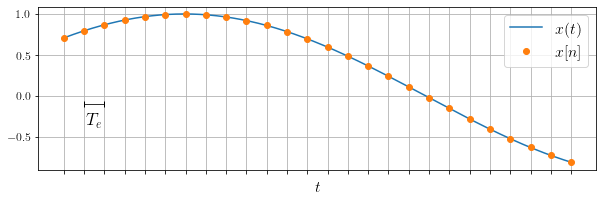

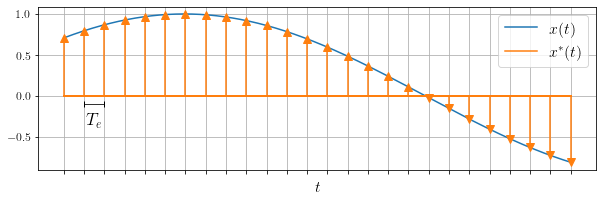

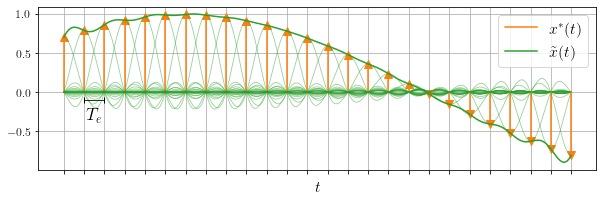

In [2]:
T = 40
N = 25*T+1

# Signal analogique
Te = 1
fe = 1/Te
fo = 1/1900
n = np.arange(N)
t = n*Te
x = np.sin(2*np.pi*fo*t + np.pi/4)

# Signal échantillonné

m = np.arange(0, N, T)
y = x[m]

def save(fname):
    fig.set_figwidth(10)
    fig.set_figheight(3)
    plt.xticks(np.arange(0, N+1, T), labels=[])
    plt.plot([T, 2*T], [-.1, -.1], "k|-", linewidth=.8)
    plt.text(T*1.5, -.2, "$T_e$", ha="center", va="top", fontsize=18)
    plt.legend()
    plt.xlabel("$t$")
    plt.savefig(f"{fname}.svg")
    plt.show()

# Signal analogique + échantillonné
fig = plt.figure()
plt.plot(n, x, "C0",  label="$x(t)$")
plt.plot(m, y, "C1o", label="$x[n]$")
save("echantillonnage-temporel-1")

# Signal analogique + peigne
fig = plt.figure()
plt.plot(n, x, "C0", label="$x(t)$")
for i in range(len(m)):
    label = "$x^*(t)$" if i==0 else ""
    plt.plot([m[i], m[i]], [0, y[i]], "C1-", label=label)
    if y[i]>0:
        plt.plot(m[i], y[i], "C1^", markersize=8)
    else:
        plt.plot(m[i], y[i], "C1v", markersize=8)
    plt.plot([0, N], [0, 0], "C1-")
save("echantillonnage-temporel-2")

# Interpolation avec sinus cardinal
w = np.zeros(len(n))
fig = plt.figure()
for i in range(len(m)):
    
    # Peigne
    label = "$x^*(t)$" if i==0 else ""
    plt.plot([m[i], m[i]], [0, y[i]], "C1-", label=label)
    if y[i]>0:
        plt.plot(m[i], y[i], "C1^", markersize=8)
    else:
        plt.plot(m[i], y[i], "C1v", markersize=8)
        
    # Sinc
    z = x[i*T] * np.sinc(t/T-i)
    w += z
    plt.plot(n, z, "C2", linewidth=.8, alpha=.5)
    
# plt.plot(n, x, "C2", label="$\\tilde{x}(t)$")
plt.plot(n, w, "C2", label="$\\tilde{x}(t)$")
    
save("echantillonnage-temporel-3")

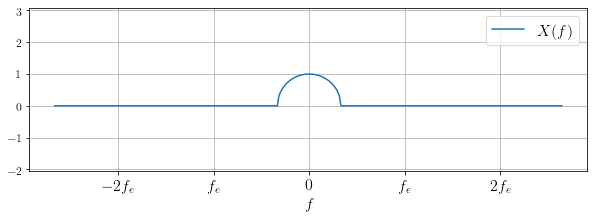

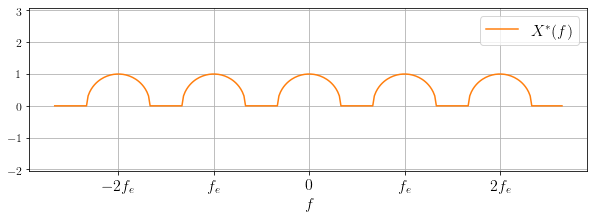

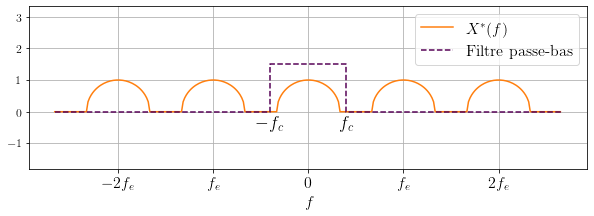

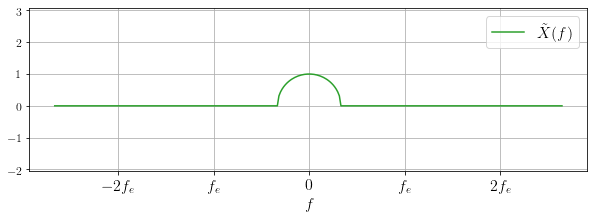

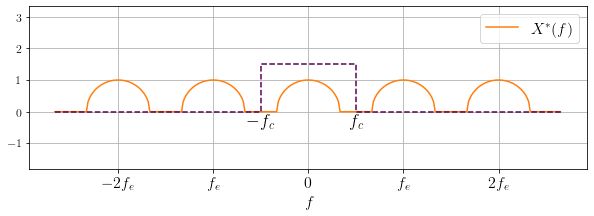

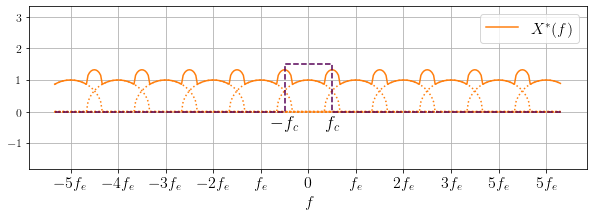

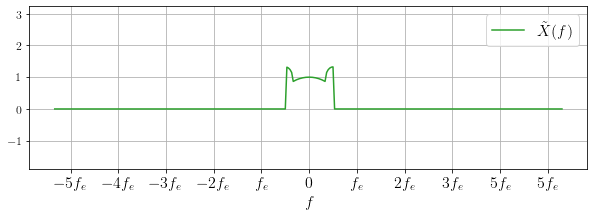

In [5]:
f = np.arange(-8, 8, .05)
fe = 3
radius = 1

def circ(f, center):
    x = np.zeros(len(f))
    n = f - center
    idx = np.where(np.abs(n) < radius)
    c = radius * np.sqrt(radius**2-n[idx]**2)
    x[idx] = c
    return x

def save(fname):
    fig.set_figwidth(10)
    fig.set_figheight(3)
    plt.xticks(np.arange(-5*fe, 5*fe+.1, fe),
               labels=['$-5f_e$', '$-4f_e$', '$-3f_e$', '$-2f_e$', '$f_e$', '$0$', '$f_e$', '$2f_e$', '$3f_e$', '$5f_e$', '$5f_e$'], fontsize=16)
    plt.legend()
    plt.xlabel("$f$")
    plt.axis('equal')
    plt.savefig(f"{fname}.svg")
    plt.show()

# Signal analogique
fig = plt.figure()
plt.plot(f, circ(f,0), "C0", label="$X(f)$")
save("echantillonnage-frequentiel-1")

# Signal échantillonné
fig = plt.figure()
plt.plot(f, circ(f,-2*fe)+circ(f,-fe)+circ(f,0)+circ(f,fe)+circ(f,2*fe), "C1", label="$X^*(f)$")
save("echantillonnage-frequentiel-2")

# Signal échantillonné + filtre
fc = fe*.4
fig = plt.figure()
plt.plot(f, circ(f,-2*fe)+circ(f,-fe)+circ(f,0)+circ(f,fe)+circ(f,2*fe), "C1", label="$X^*(f)$")
plt.plot([-8, -fc, -fc, fc, fc, 8], [0, 0, 1.5, 1.5, 0, 0], color="#550055", linestyle="--", label="Filtre passe-bas")
plt.text(-fc, -.1, "$-f_c$", ha="center", va="top", fontsize=18)
plt.text( fc, -.1,  "$f_c$", ha="center", va="top", fontsize=18)
save("echantillonnage-frequentiel-3")

# Signal après passe-bas
fig = plt.figure()
plt.plot(f, circ(f,0), "C2", label="$\\tilde{X}(f)$")
save("echantillonnage-frequentiel-4")

# Signal échantillonné + filtre
fc = fe*.5
fig = plt.figure()
plt.plot(f, circ(f,-2*fe)+circ(f,-fe)+circ(f,0)+circ(f,fe)+circ(f,2*fe), "C1", label="$X^*(f)$")
plt.plot([-8, -fc, -fc, fc, fc, 8], [0, 0, 1.5, 1.5, 0, 0], color="#550055", linestyle="--")
plt.text(-fc, -.05, "$-f_c$", ha="center", va="top", fontsize=18)
plt.text( fc, -.05,  "$f_c$", ha="center", va="top", fontsize=18)
save("echantillonnage-frequentiel-5")

# Signal échantillonné (repliement spectral)
fe = 1.5
X = 0
fig = plt.figure()
for k in range(-7,8):
    X += circ(f,k*fe)
    plt.plot(f, circ(f,k*fe), "C1", linestyle=":")
fc = fe*.5
plt.plot(f, X, "C1", label="$X^*(f)$")
plt.plot([-8, -fc, -fc, fc, fc, 8], [0, 0, 1.5, 1.5, 0, 0], color="#550055", linestyle="--")
plt.text(-fc, -.1, "$-f_c$", ha="center", va="top", fontsize=18)
plt.text( fc, -.1,  "$f_c$", ha="center", va="top", fontsize=18)
save("echantillonnage-frequentiel-6")

# Signal échantillonné + filtre (repliement spectral)
X[ np.where(np.abs(f)>fc) ] = 0
fig = plt.figure()
plt.plot(f, X, "C2", label="$\\tilde{X}(f)$")
save("echantillonnage-frequentiel-7")